# Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')


# Подготовка полного датасета

In [ ]:
# Загружаем данные
titanic = sns.load_dataset('titanic')

# Выбираем признаки (целевая переменная: 'survived')
# Исключаем признаки, которые дублируют информацию или имеют слишком много пропусков
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

df = titanic[features + [target]].copy()

print("Исходный размер:", df.shape)
print("\nПропуски до обработки:\n", df.isnull().sum())

Исходный размер: (891, 8)

Пропуски до обработки:
 pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64


# Обработка пропусков и кодирование

In [ ]:
# Определяем числовые и категориальные признаки
numeric_features = ['age', 'sibsp', 'parch', 'fare']
categorical_features = ['pclass', 'sex', 'embarked']

# Создаём пайплайны для разных типов признаков
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # заполняем пропуски медианой
    ('scaler', StandardScaler())                     # стандартизация
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),  # заполняем модой
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # one-hot кодирование
])

# Объединяем в ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Разделение на обучающую и тестовую выборки

In [ ]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (712, 7)
Размер тестовой выборки: (179, 7)


# предобработка + KNN

In [ ]:
# Базовый пайплайн с произвольным K=5
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5))
])

# Обучаем модель с произвольным K
knn_pipeline.fit(X_train, y_train)
y_pred_default = knn_pipeline.predict(X_test)

# Оценка качества модели с K=5
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ МОДЕЛИ С ПРОИЗВОЛЬНЫМ K=5")
print("="*50)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_default):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_default):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_default):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred_default):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_default))


РЕЗУЛЬТАТЫ МОДЕЛИ С ПРОИЗВОЛЬНЫМ K=5
Accuracy:  0.8156
Precision: 0.8103
Recall:    0.6812
F1-score:  0.7402

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.68      0.74        69

    accuracy                           0.82       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.82      0.82      0.81       179



Подбор гиперпараметра K с GridSearchCV

In [ ]:
# Стратегия кросс-валидации №1: StratifiedKFold (сохраняет баланс классов)
stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Параметры для поиска
param_grid = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11, 13, 15, 21, 31],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

grid_search = GridSearchCV(
    estimator=knn_pipeline,
    param_grid=param_grid,
    cv=stratified_kfold,
    scoring='f1',  # оптимизируем F1-score
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nЛучшие параметры (GridSearchCV): {grid_search.best_params_}")
print(f"Лучший F1-score на CV: {grid_search.best_score_:.4f}")

# Оценка лучшей модели на тестовой выборке
best_grid_model = grid_search.best_estimator_
y_pred_grid = best_grid_model.predict(X_test)

print(f"\nТестовая оценка лучшей модели (GridSearchCV):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_grid):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_grid):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_grid):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred_grid):.4f}")


ПОДБОР ГИПЕРПАРАМЕТРОВ С GridSearchCV
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучшие параметры (GridSearchCV): {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 21, 'classifier__weights': 'uniform'}
Лучший F1-score на CV: 0.7524

Тестовая оценка лучшей модели (GridSearchCV):
  Accuracy:  0.7821
  Precision: 0.7586
  Recall:    0.6377
  F1-score:  0.6929


# Подбор гиперпараметра с RandomizedSearchCV

In [ ]:
# Стратегия кросс-валидации №2: KFold (обычная, 10 фолдов)
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# Более широкий диапазон параметров для случайного поиска
param_dist = {
    'classifier__n_neighbors': list(range(1, 51)),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'chebyshev', 'minkowski'],
    'classifier__p': [1, 2]  # для minkowski: p=1 (манхэттен), p=2 (евклид)
}

random_search = RandomizedSearchCV(
    estimator=knn_pipeline,
    param_distributions=param_dist,
    n_iter=50,  # количество случайных комбинаций
    cv=kfold,
    scoring='f1',
    n_jobs=-1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train, y_train)

print(f"\nЛучшие параметры (RandomizedSearchCV): {random_search.best_params_}")
print(f"Лучший F1-score на CV: {random_search.best_score_:.4f}")

# Оценка лучшей модели на тестовой выборке
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_test)

print(f"\nТестовая оценка лучшей модели (RandomizedSearchCV):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_random):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_random):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_random):.4f}")
print(f"  F1-score:  {f1_score(y_test, y_pred_random):.4f}")

Fitting 10 folds for each of 50 candidates, totalling 500 fits

Лучшие параметры (RandomizedSearchCV): {'classifier__weights': 'uniform', 'classifier__p': 1, 'classifier__n_neighbors': 25, 'classifier__metric': 'minkowski'}
Лучший F1-score на CV: 0.7541

Тестовая оценка лучшей модели (RandomizedSearchCV):
  Accuracy:  0.7933
  Precision: 0.7667
  Recall:    0.6667
  F1-score:  0.7132


# Сравнение метрик качества

                                   Модель  Accuracy  Precision   Recall  F1-score
                   KNN (произвольный K=5)  0.815642   0.810345 0.681159  0.740157
      KNN (GridSearchCV оптимизированный)  0.782123   0.758621 0.637681  0.692913
KNN (RandomizedSearchCV оптимизированный)  0.793296   0.766667 0.666667  0.713178


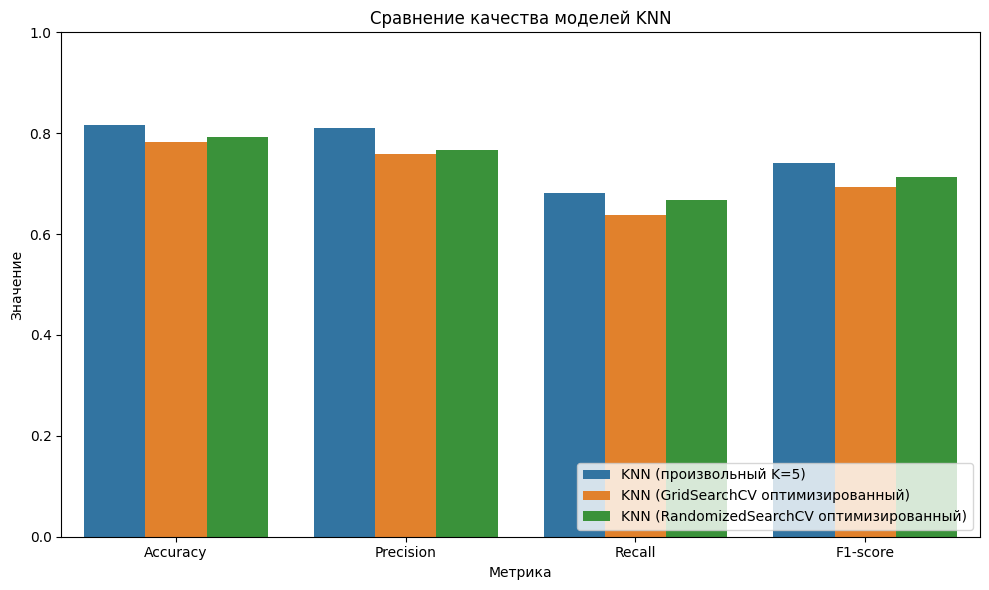

In [ ]:
results = pd.DataFrame({
    'Модель': ['KNN (произвольный K=5)', 'KNN (GridSearchCV оптимизированный)', 'KNN (RandomizedSearchCV оптимизированный)'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_default),
        accuracy_score(y_test, y_pred_grid),
        accuracy_score(y_test, y_pred_random)
    ],
    'Precision': [
        precision_score(y_test, y_pred_default),
        precision_score(y_test, y_pred_grid),
        precision_score(y_test, y_pred_random)
    ],
    'Recall': [
        recall_score(y_test, y_pred_default),
        recall_score(y_test, y_pred_grid),
        recall_score(y_test, y_pred_random)
    ],
    'F1-score': [
        f1_score(y_test, y_pred_default),
        f1_score(y_test, y_pred_grid),
        f1_score(y_test, y_pred_random)
    ]
})

print(results.to_string(index=False))

# Визуализация сравнения
fig, ax = plt.subplots(figsize=(10, 6))
results_melted = results.melt(id_vars='Модель', var_name='Метрика', value_name='Значение')
sns.barplot(data=results_melted, x='Метрика', y='Значение', hue='Модель', ax=ax)
ax.set_title('Сравнение качества моделей KNN')
ax.set_ylim(0, 1)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()